In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec

import scanpy as sc

import os

import scvi

import seaborn as sns


def order_m(m):
    n = min(*m.shape)
    
    ordered_cols = []
    remain_cols = list(range(m.shape[1]))
    
    for i in range(n):
        ic = m[i, remain_cols].argmax()
        c = remain_cols[ic]
        ordered_cols.append(c)
        remain_cols.remove(c)
    
    return ordered_cols, remain_cols

# Some canonical markers for PBMC cell types that I found
canonical_markers = ["IL32", "LTB", "CD3D",
    "IL7R", "LDHB", "FCGR3A", 
    "CD68", "MS4A1", "GNLY", 
    "CD3E", "CD14", "CD14", 
    "FCGR3A", "LYZ", "PPBP", 
    "CD8A", "PPBP", "CST3", 
    "NKG7", "MS4A7", "MS4A1", 
    "CD8A", "CD4", "NCAM1"]

    

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndat

## Load entropy results

In [2]:
# Load Cell Ranger  RNA filtering criteria barcodes
CR_rnamodality_BC_file = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/rna/VIB_10xmultiome_2_rna/outs/filtered_feature_bc_matrix/barcodes.tsv'
CR_rnamodality_bc = pd.read_csv(CR_rnamodality_BC_file, header=None, sep='\t', names=['barcodes'])

# Load Cell Ranger ATAC filtering criteria barcodes
CR_atacmodality_BC_file ='/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/atac/VIB_10xmultiome_2/outs/filtered_peak_bc_matrix/barcodes.tsv'
CR_atacmodality_bc = pd.read_csv(CR_atacmodality_BC_file, header=None, sep='\t', names=['barcodes'])

CR_rnamodality_bc['rna_bc'] = CR_rnamodality_bc['barcodes'].map(lambda x: x.split('-1')[0])
CR_atacmodality_bc['atac_bc'] = CR_atacmodality_bc['barcodes'].map(lambda x: x.split('-1')[0])


# Load Entropy value for each barcode on atac 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
entropy_df_file = os.path.join(entropy_dir, 'chr1_barcode_entropy_df.tsv')
entropy_df = pd.read_csv(entropy_df_file, sep=',', index_col=0)
entropy_df['log10_Entropy'] = np.log10(entropy_df['Entropy'])
entropy_df['atac_bc'] = entropy_df.index.map(lambda x: x.split('-1')[0])



entropy_filtered_bc_file = os.path.join(entropy_dir, 'entropy_filtered_bc_df.tsv')
entropy_filtered_bc_df = pd.read_csv(entropy_filtered_bc_file, sep=',', index_col=0)
entropy_filtered_bc_df['atac_bc'] = entropy_filtered_bc_df.index.map(lambda x: x.split('-1')[0])

# Load Entropy filtered atac barcodes
# Use entropy_peak.obs or peak.obs # TODO: Change to be entropy_passed barcodes file 

# Load  atac-rna-barcode map 
bc_map_file = '/home/syyang/adipose_ln/multiom/atac_rna_barcodes_map.tsv'
bc_map_pd = pd.read_csv(bc_map_file, sep='\t')

# Summary statistics about Fraction of Reads in Peaks (FRIP)
standard_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_peaks.csv')
entropy_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_entropypeaks.csv')


standard_peak_frip = pd.read_csv(standard_peak_frip_file, index_col=None, sep='\t')
entropy_peak_frip = pd.read_csv(entropy_peak_frip_file, index_col=None, sep='\t')
standard_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip['atac_bc'] = entropy_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip['atac_bc'] = standard_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip.set_index('atac_bc', inplace=True)
entropy_peak_frip.set_index('atac_bc', inplace=True)


## Load Fragments overlap CR-called peaks counts 
CR_frag_overlap_CRpeaks_file = os.path.join(entropy_dir, '_CRpipe_peak_frag_overlap_peak', 'overlap_peaks_counts.txt')
CR_frag_overlap_CRpeaks = pd.read_csv(CR_frag_overlap_CRpeaks_file, sep=' ', index_col=1, header=None)
CR_frag_overlap_CRpeaks.columns = ['frag_overlap_CRpeaks']
CR_frag_overlap_CRpeaks.index.name = None
CR_frag_overlap_CRpeaks['atac_bc'] = CR_frag_overlap_CRpeaks.index.map(lambda x: x.split('-1')[0])
CR_frag_overlap_CRpeaks.reset_index(inplace=True, drop=False)
CR_frag_overlap_CRpeaks.set_index('atac_bc', inplace=True)

# load AMULET doublet detection results
AMULET_doublet_file = os.path.join(entropy_dir, '_UnionBC_fragments/AMULET_output/MultipletProbabilities.txt')
AMULET_doublet_df = pd.read_csv(AMULET_doublet_file, sep='\t', index_col=0)
AMULET_doublet_df['atac_bc'] = AMULET_doublet_df.index.map(lambda x: x.split('-1')[0])
AMULET_doublet_df.reset_index(inplace=True, drop=False)
AMULET_doublet_df.set_index('atac_bc', inplace=True)
AMULET_doublet_df = AMULET_doublet_df.rename(columns={'p-value': 'AMULET_pvalue', 'q-value': 'AMULET_qvalue'}, inplace=False)

In [3]:
AMULET_doublet_df.head()

,cell_id,barcode,AMULET_pvalue,AMULET_qvalue
atac_bc,,,,
AAACAAGCAAGTTAGT,AAACAAGCAAGTTAGT-1,AAACAAGCAAGTTAGT-1,1.0,1.0
AAACAAGCATTTCTTC,AAACAAGCATTTCTTC-1,AAACAAGCATTTCTTC-1,1.0,1.0
AAACCGCCAACGGTAC,AAACCGCCAACGGTAC-1,AAACCGCCAACGGTAC-1,1.0,1.0
AAACCGCCAGAAACCC,AAACCGCCAGAAACCC-1,AAACCGCCAGAAACCC-1,1.0,1.0
AAACGAACACCTGTAT,AAACGAACACCTGTAT-1,AAACGAACACCTGTAT-1,1.0,1.0


In [4]:
if 'standard_peak_FRIP' in entropy_df.columns:
    entropy_df.drop(columns=['standard_peak_FRIP'], inplace=True)
if 'entropy_peak_FRIP' in entropy_df.columns:
    entropy_df.drop(columns=['entropy_peak_FRIP'], inplace=True)
if 'total_fragments' in entropy_df.columns:
    entropy_df.drop(columns=['total_fragments'], inplace=True)
if 'Nfrag_overlap_standard_peak' in entropy_df.columns:
    entropy_df.drop(columns=['Nfrag_overlap_standard_peak'], inplace=True)
if 'Nfrag_overlap_entropy_peak' in entropy_df.columns:
    entropy_df.drop(columns=['Nfrag_overlap_entropy_peak'], inplace=True)
    
if 'frag_overlap_CRpeaks' in entropy_df.columns:
    entropy_df.drop(columns=['frag_overlap_CRpeaks'], inplace=True)

entropy_df = entropy_df.merge(standard_peak_frip[['frag_overlap_peaks%', 'total_fragments', 'frag_overlap_peaks']].rename(
    columns={'frag_overlap_peaks%': 'standard_peak_FRIP', 'frag_overlap_peaks': 'Nfrag_overlap_standard_peak'}),\
    left_on='atac_bc', right_index=True, how='left')
entropy_df = entropy_df.merge(entropy_peak_frip[['frag_overlap_entropy_peaks%', 'frag_overlap_entropy_peaks']].rename(
    columns={'frag_overlap_entropy_peaks%': 'entropy_peak_FRIP', 'frag_overlap_entropy_peaks': 'Nfrag_overlap_entropy_peak'}),\
    left_on='atac_bc', right_index=True, how='left')
entropy_df = entropy_df.merge(CR_frag_overlap_CRpeaks[['frag_overlap_CRpeaks']],\
    left_on='atac_bc', right_index=True, how='left')

entropy_df['total_fragment_log1p'] = np.log1p(entropy_df['total_fragments'])

entropy_df['CRpeak_FRIP'] = entropy_df['frag_overlap_CRpeaks'] / entropy_df['total_fragments'] * 100

### Match RNA and ATAC abrcodes

In [5]:
bc_map = bc_map_pd.set_index('atac_barcodes')

if entropy_df.index.name != 'atac_barcodes':
    entropy_df.set_index('atac_bc', inplace=True)
    entropy_df.index.name = 'atac_barcodes'
    entropy_df['atac_bc'] = entropy_df.index.values
    
if 'rna_barcodes' not in entropy_df.columns:
    entropy_df = entropy_df.join(bc_map, how='inner')
    

entropy_df.shape

(33287, 17)

In [6]:
entropy_df['rna_pass_CR'] = entropy_df['rna_barcodes'].isin(CR_rnamodality_bc['rna_bc'])
entropy_df['atac_pass_CR'] = entropy_df['atac_bc'].isin(CR_atacmodality_bc['atac_bc'])
entropy_df['atac_pass_entropy'] = entropy_df['atac_bc'].isin(entropy_filtered_bc_df['atac_bc'])

In [7]:
entropy_df['identified_by_atac'] = entropy_df.apply(
    lambda row: 'both' if row['atac_pass_entropy'] and row['atac_pass_CR'] else 
                ('entropy_only' if row['atac_pass_entropy'] and not row['atac_pass_CR'] else 
                 ('cr_only' if not row['atac_pass_entropy'] and row['atac_pass_CR'] else 'none')), axis=1
)

entropy_df['identified_by_atac_binary'] = entropy_df.apply(
    lambda row: 1 if row['identified_by_atac'] != 'none' else 0, axis=1
)

entropy_df['identified_by_atac_binary'].sum(), entropy_df.groupby('identified_by_atac').size()


(2185,
 identified_by_atac
 both             1887
 cr_only            59
 entropy_only      239
 none            31102
 dtype: int64)

## Load h5ads 

In [8]:
## Downloaded CR-arc count matrix results
data_dir = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/downloaded_counts/VIB_10xmultiome_2'

h5_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2-outs-raw_feature_bc_matrix-matrix.h5ad')

barcodes_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.barcodes.tsv')

features_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.features.tsv')

h5 = sc.read_h5ad(h5_file)

features_pd = pd.read_csv(features_file, header=None, sep='\t')

barcodes_pd = pd.read_csv(barcodes_file, header=None, sep='\t')

## It's feature -by- barcode matrix, need to transpose
h5.var = barcodes_pd
h5.obs = features_pd 
h5.obs.columns = ['feature_id', 'name', 'feature_type', 'chrom', 'start', 'end']
h5.var.columns = ['barcodes']


## Entropy filtered atac
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
entropy_downstream_dir = os.path.join(entropy_dir, 'DownstreamReanalysis')
entropy_peak_file = os.path.join(entropy_downstream_dir, 'entropy_peakvi.h5ad')
peak_file = os.path.join(entropy_downstream_dir, 'peakvi.h5ad')

entropy_peak = sc.read_h5ad(entropy_peak_file)
peak = sc.read_h5ad(peak_file)


In [9]:
entropy_peak, peak, h5, features_pd.shape, barcodes_pd.shape, bc_map_pd.shape

(AnnData object with n_obs × n_vars = 2125 × 36729
     obs: 'barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi'
     var: 'peak'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'clusters_peakvi', 'neighbors', 'umap'
     obsm: 'X_peakvi', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 2125 × 31116
     obs: 'barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi'
     var: 'peak'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'clusters_peakvi', 'neighbors', 'umap'
     obsm: 'X_peakvi', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 104068 × 687495
     obs: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end'
     var: 'barcodes',
 (104068, 6),
 (687495, 1),
 (736320, 2))

In [10]:
bc_passed_entropy_df = entropy_df.loc[entropy_df['identified_by_atac_binary'] == 1].copy()

entropy_passed_bc_map=bc_passed_entropy_df.reset_index(inplace=False)
entropy_passed_bc_map.set_index('rna_barcodes', inplace=True)
entropy_passed_bc_map.head()

,atac_barcodes,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,log10_Entropy,standard_peak_FRIP,total_fragments,...,Nfrag_overlap_entropy_peak,frag_overlap_CRpeaks,total_fragment_log1p,CRpeak_FRIP,atac_bc,rna_pass_CR,atac_pass_CR,atac_pass_entropy,identified_by_atac,identified_by_atac_binary
rna_barcodes,,,,,,,,,,,,,,,,,,,,,
CCTAAATCAATTAAGG,TCGCTAGGTTGCAATC,0.078556,0.621950,108,0.144662,0.865315,0.990337,-1.104818,4.101562,1536,...,67.0,92.0,7.337588,5.989583,TCGCTAGGTTGCAATC,False,False,True,entropy_only,1
TTGTTCCCAGTGAACG,TTTCAAGGTATGTTGC,0.212087,0.179513,74,0.026906,0.973452,0.966411,-0.673487,2.464066,1461,...,40.0,67.0,7.287561,4.585900,TTTCAAGGTATGTTGC,False,False,True,entropy_only,1
AATGTCCAGGGTCCAC,TACCTAGTCATAGCTT,0.104258,2.004919,775,1.149601,0.316763,0.986331,-0.981890,2.004854,9477,...,225.0,370.0,9.156729,3.904189,TACCTAGTCATAGCTT,False,True,True,both,1
ATGGCTTAGGAGCAAC,CGGTTTATCCTAAATC,0.242614,0.219806,114,0.034885,0.965717,0.959930,-0.615084,1.618123,1236,...,23.0,50.0,7.120444,4.045307,CGGTTTATCCTAAATC,False,False,True,entropy_only,1
TCAAGGAAGCGAGCGA,TGCGGAATCGATATAG,0.157488,0.208608,61,0.032610,0.967916,0.977089,-0.802751,10.370370,540,...,58.0,73.0,6.293419,13.518519,TGCGGAATCGATATAG,False,False,True,entropy_only,1


# RNA clustering

In [11]:
# prepare for rna-bc correspondence to atac entropy filtered barcodes
bc_passed_entropy_df = entropy_df.loc[entropy_df['identified_by_atac_binary'] == 1].copy()

entropy_passed_bc_map=bc_passed_entropy_df.reset_index(inplace=False)
entropy_passed_bc_map.set_index('rna_barcodes', inplace=True)


h5_rna_ = h5.transpose()
h5_rna_.obs['rna_barcodes'] = h5_rna_.obs['barcodes'].map(lambda x: x.split('-1')[0])
h5_rna_.obs.set_index('rna_barcodes', inplace=True)


# select gene expression only, and only the barcodes that passed entropy filtering
h5_rna_ = h5_rna_[:, h5_rna_.var['feature_type'] == 'Gene Expression']
h5_rna_ = h5_rna_[h5_rna_.obs.index.isin(entropy_passed_bc_map.index), :]
h5_rna_.obs = h5_rna_.obs.join(entropy_passed_bc_map, how='inner')

# calculate total RNA QC metrics
h5_rna_.obs['total_RNA_UMI'] = h5_rna_.X.sum(axis=1)
h5_rna_.obs['total_RNA_UMI_log'] = np.log1p(h5_rna_.obs['total_RNA_UMI'])
h5_rna_.obs['n_genes_by_RNA_counts'] = (h5_rna_.X > 0).sum(axis=1)
h5_rna_.obs['N_MT_counts'] = h5_rna_.X[:, h5_rna_.var.name.apply(lambda x: x.startswith('MT-'))].sum(axis=1)
h5_rna_.obs['MT%'] = h5_rna_.obs['N_MT_counts'] / h5_rna_.obs['total_RNA_UMI'] * 100

X_10k = sc.pp.normalize_total(h5_rna_, target_sum=1e4, inplace=False)['X']
h5_rna_.layers['log1p_counts'] = np.log1p(X_10k.copy())

h5_rna = h5_rna_[:, ~h5_rna_.var.name.apply(lambda x: x.startswith('MT-'))].copy() # Remove MT genes

# Add gene_name column 
h5_rna.var['gene_name'] = h5_rna.var['name'].astype(str)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


In [12]:
h5_rna, h5_rna_.shape

(AnnData object with n_obs × n_vars = 2185 × 36588
     obs: 'barcodes', 'atac_barcodes', 'Entropy', 'Entropy_open_region', 'Mp', 'mle_lambda', 'P0_open_region', 'P_closed_state', 'log10_Entropy', 'standard_peak_FRIP', 'total_fragments', 'Nfrag_overlap_standard_peak', 'entropy_peak_FRIP', 'Nfrag_overlap_entropy_peak', 'frag_overlap_CRpeaks', 'total_fragment_log1p', 'CRpeak_FRIP', 'atac_bc', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'identified_by_atac', 'identified_by_atac_binary', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end', 'gene_name'
     layers: 'log1p_counts',
 (2185, 36601))

In [13]:
sc.pp.filter_genes(h5_rna, min_counts=3)
h5_rna.raw = h5_rna # keep full dimension safe
h5_rna.layers['counts'] = h5_rna.X
sc.pp.highly_variable_genes(
h5_rna,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

In [14]:
SCVI_LATENT_KEY = "RNA_scVI"
SCVI_CLUSTERS_KEY = "leiden_RNA_scVI"

scvi.settings.seed = 0
scvi.model.SCVI.setup_anndata(h5_rna, layer="counts")
vae = scvi.model.SCVI(h5_rna, n_layers=3, n_latent=30, gene_likelihood="nb")
vae.train()

h5_rna.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()

print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
vae_model_folder=os.path.join(entropy_dir, "_unioncells_RNA_scvi_model")
vae.save(vae_model_folder, overwrite=True)
# vae_model_folder=os.path.join(entropy_dir, "RNA_scvi_model")
# vae =scvi.model.SCVI.load(vae_model_folder, adata=h5_rna)
# h5_rna.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()
# sc.pp.neighbors(h5_rna, use_rep=SCVI_LATENT_KEY)
# sc.tl.umap(h5_rna, min_dist=0.3)


# clustering using scVI latent representation via Leiden
atac_resolution = 0.5
sc.pp.neighbors(h5_rna, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(h5_rna, min_dist=0.3)
sc.tl.leiden(h5_rna, key_added=SCVI_CLUSTERS_KEY, resolution=atac_resolution + 0.1)

Seed set to 0
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/_scvi.py:168: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/gener

Epoch 400/400: 100%|██████████| 400/400 [01:37<00:00,  4.07it/s, v_num=1, train_loss_step=5.28e+3, train_loss_epoch=5.18e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [01:37<00:00,  4.11it/s, v_num=1, train_loss_step=5.28e+3, train_loss_epoch=5.18e+3]
Save integrated samples into .h5ad file and trained SCVI model into subfolder



/tmp/ipykernel_2196594/3817777607.py:25: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(h5_rna, key_added=SCVI_CLUSTERS_KEY, resolution=atac_resolution + 0.1)


### Vis on RNA spcae

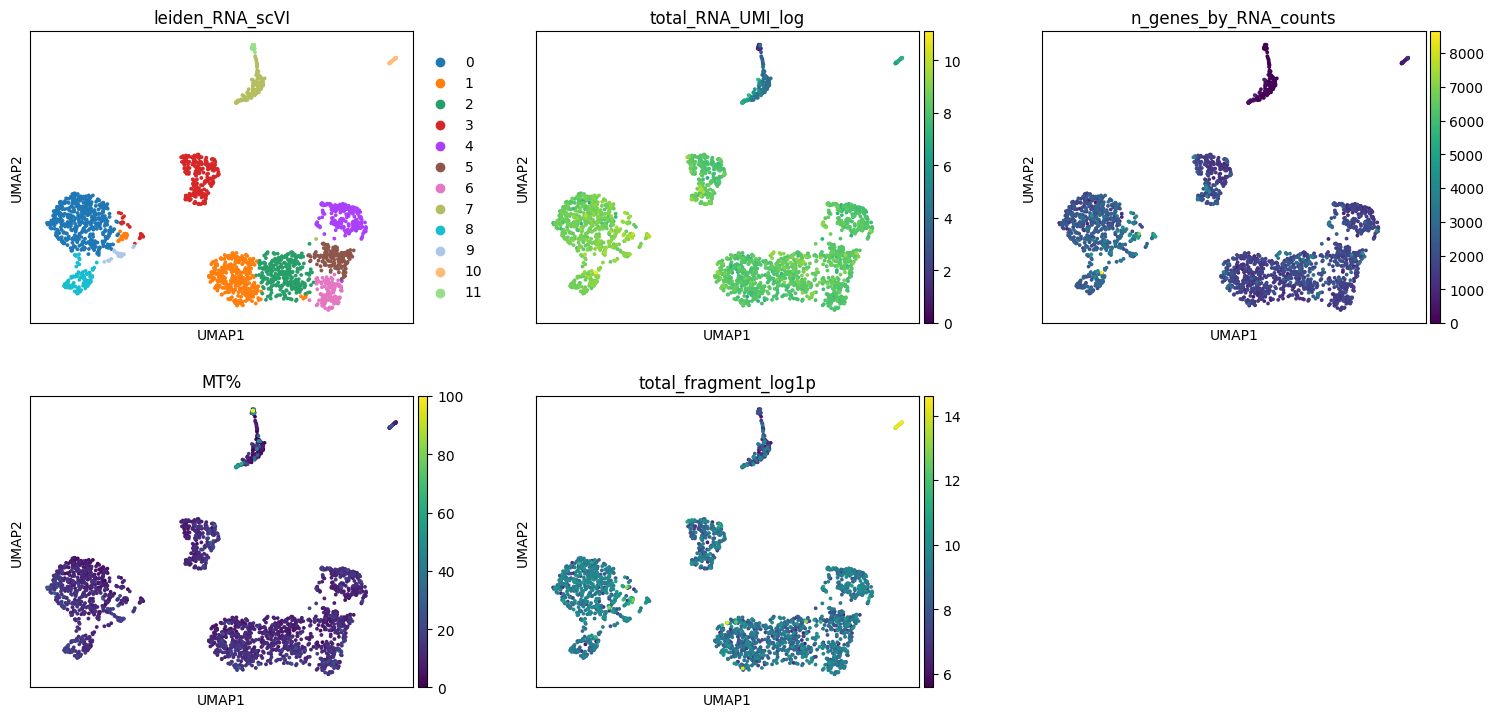

In [15]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna, color=['leiden_RNA_scVI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'MT%', 'total_fragment_log1p'], wspace=0.2, size=30, ncols=3)

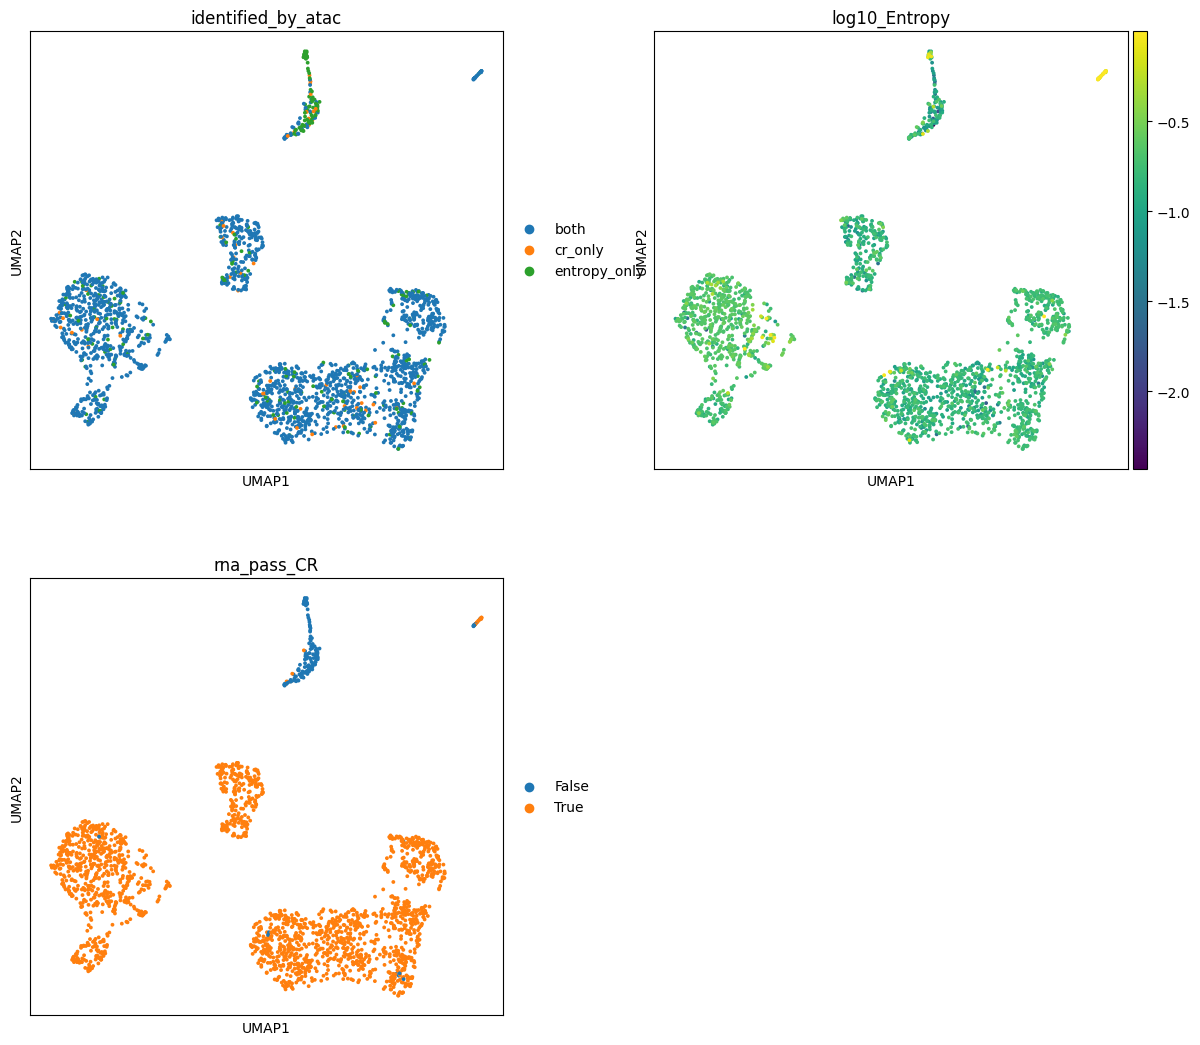

In [16]:
with plt.rc_context({'figure.figsize': (6, 6)}):
    sc.pl.umap(h5_rna, color=['identified_by_atac', 'log10_Entropy', 'rna_pass_CR'], wspace=0.2, size=30, ncols=2)

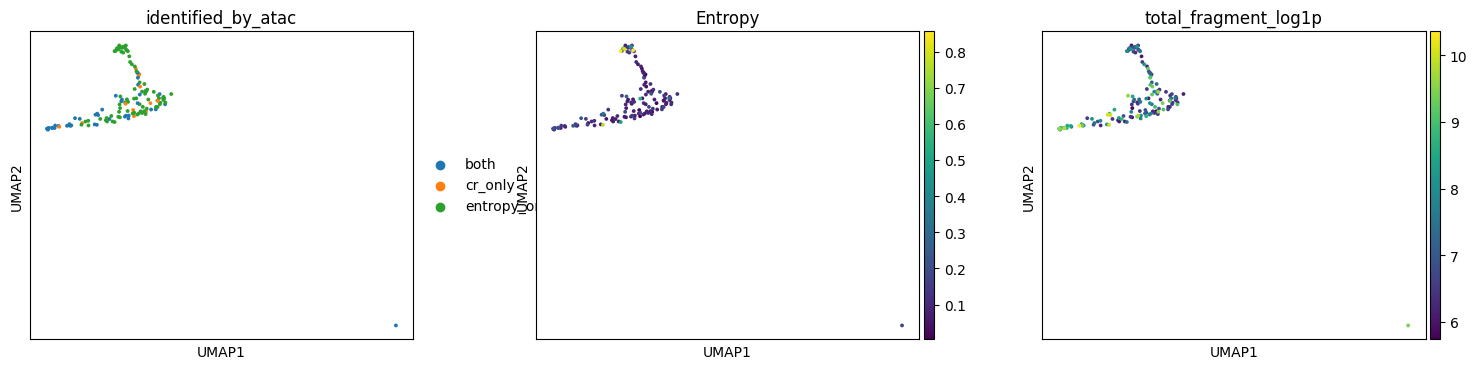

In [30]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna[(h5_rna.obs['leiden_RNA_scVI'] == '7') | (h5_rna.obs['leiden_RNA_scVI'] == '11')], color=['identified_by_atac', 'Entropy', 'total_fragment_log1p'], wspace=0.2, size=30, ncols=3)

In [31]:
h5_rna.obs.groupby(['leiden_RNA_scVI', 'identified_by_atac']).size().unstack()

/tmp/ipykernel_223282/3695852076.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna.obs.groupby(['leiden_RNA_scVI', 'identified_by_atac']).size().unstack()


identified_by_atac,both,cr_only,entropy_only
leiden_RNA_scVI,,,
0,445,10,38
1,331,8,26
2,259,15,22
3,214,11,21
4,196,0,19
5,140,1,10
6,118,1,10
7,43,12,62
8,96,1,7


In [32]:
Ncells_table = h5_rna.obs.groupby(['leiden_RNA_scVI', 'identified_by_atac']).size().unstack()
Ncells_table/Ncells_table.sum(axis=0) * 100

/tmp/ipykernel_223282/2009207566.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Ncells_table = h5_rna.obs.groupby(['leiden_RNA_scVI', 'identified_by_atac']).size().unstack()


identified_by_atac,both,cr_only,entropy_only
leiden_RNA_scVI,,,
0,23.582406,16.949153,15.899582
1,17.541070,13.559322,10.878661
2,13.725490,25.423729,9.205021
3,11.340753,18.644068,8.786611
4,10.386857,0.000000,7.949791
5,7.419184,1.694915,4.184100
6,6.253312,1.694915,4.184100
7,2.278749,20.338983,25.941423
8,5.087440,1.694915,2.928870


<Axes: xlabel='leiden_RNA_scVI', ylabel='count'>

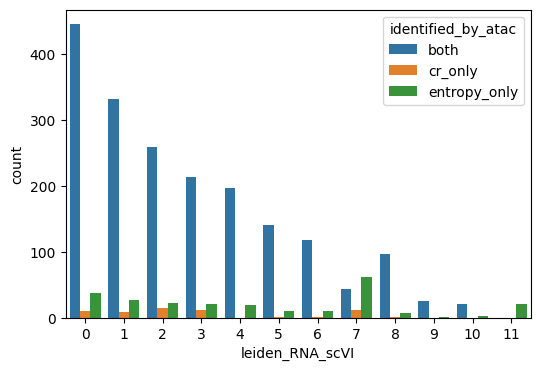

In [46]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=h5_rna.obs, x='leiden_RNA_scVI', hue='identified_by_atac', ax=ax)

## Check Doublet schore 

In [36]:
h5_rna.obs.drop(columns=['AMULET_pvalue_y', 'AMULET_pvalue_x', 'AMULET_qvalue_y', 'AMULET_qvalue_x'], inplace=True)

In [37]:
if 'AMULET_qvalue' not in h5_rna.obs.columns :
    h5_rna.obs = h5_rna.obs.merge(AMULET_doublet_df[['AMULET_pvalue', 'AMULET_qvalue']], left_on='atac_bc', right_index=True, how='left')
    h5_rna.obs['AMULET_doublet'] = h5_rna.obs['AMULET_qvalue'] < 0.05

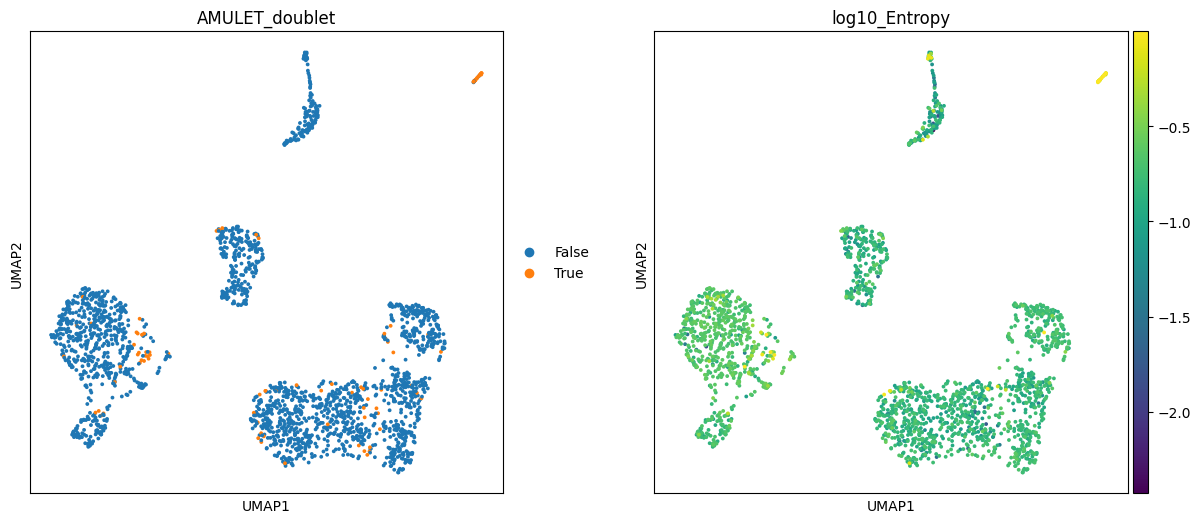

In [39]:
with plt.rc_context({'figure.figsize': (6, 6)}):
    sc.pl.umap(h5_rna, color=['AMULET_doublet', 'log10_Entropy'], wspace=0.2, size=30, ncols=2)

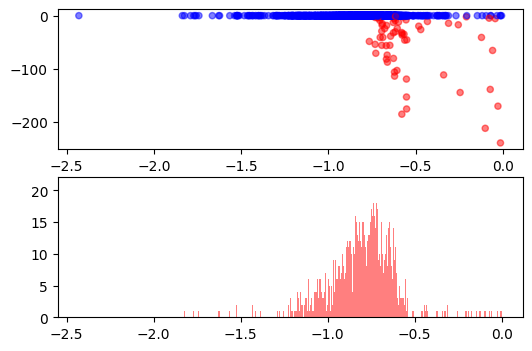

In [ ]:
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(6, 4))
ax[0].scatter( h5_rna.obs['log10_Entropy'], np.log10(h5_rna.obs['AMULET_qvalue']), c=h5_rna.obs['AMULET_doublet'].map({True: 'red', False: 'blue'}), alpha=0.5, s=20)

_ = ax[1].hist(h5_rna.obs['log10_Entropy'], bins=100, alpha=0.5, label='Doublets', color='red')

In [44]:
h5_rna.obs.groupby(['AMULET_doublet', 'identified_by_atac']).size().unstack()

/tmp/ipykernel_223282/3685671454.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna.obs.groupby(['AMULET_doublet', 'identified_by_atac']).size().unstack()


identified_by_atac,both,cr_only,entropy_only
AMULET_doublet,,,
False,1796,59,238
True,91,0,1


## ATAC clsutering

In [ ]:
# prepare for rna-bc correspondence to atac entropy filtered barcodes
bc_passed_entropy_df = entropy_df.loc[entropy_df['identified_by_atac_binary'] == 1].copy()

entropy_passed_bc_map=bc_passed_entropy_df.reset_index(inplace=False)
entropy_passed_bc_map.set_index('rna_barcodes', inplace=True)


h5_atac_ = h5.transpose()
h5_atac_.obs['rna_barcodes'] = h5_atac_.obs['barcodes'].map(lambda x: x.split('-1')[0])
h5_atac_.obs.set_index('rna_barcodes', inplace=True)


# select gene expression only, and only the barcodes that passed entropy filtering
h5_atac_ = h5_atac_[:, h5_atac_.var['feature_type'] == 'Peaks']
h5_atac_ = h5_atac_[h5_atac_.obs.index.isin(entropy_passed_bc_map.index), :]
h5_atac_.obs = h5_atac_.obs.join(entropy_passed_bc_map, how='inner')


# Add gene_name column 
h5_atac_.var['peak_name'] = h5_atac_.var.apply(lambda x: x['chrom'] + ':' + str(x['start']) + '-' + str(x['end']), axis=1)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [80]:
h5_atac_

AnnData object with n_obs × n_vars = 2185 × 67467
    obs: 'barcodes', 'atac_barcodes', 'Entropy', 'Entropy_open_region', 'Mp', 'mle_lambda', 'P0_open_region', 'P_closed_state', 'log10_Entropy', 'standard_peak_FRIP', 'total_fragments', 'Nfrag_overlap_standard_peak', 'entropy_peak_FRIP', 'Nfrag_overlap_entropy_peak', 'frag_overlap_CRpeaks', 'total_fragment_log1p', 'CRpeak_FRIP', 'atac_bc', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'identified_by_atac', 'identified_by_atac_binary'
    var: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end', 'peak_name'

In [81]:
PEAKVI_LATENT_KEY = "X_peakvi"
PEAKVI_CLUSTERS_KEY = "leiden_atac"

scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)
#%%
# filter regions with less than 3% of the cells
# print("# regions before filtering:", h5_atac_.shape[-1])
# sc.pp.filter_genes(h5_atac_, min_cells=10)

# train on atac_adata
scvi.model.PEAKVI.setup_anndata(h5_atac_)
peak_model = scvi.model.PEAKVI(h5_atac_)
peak_model.train()

# save latent representation back adata
latent = peak_model.get_latent_representation()
h5_atac_.obsm[PEAKVI_LATENT_KEY] = latent


# save model
print("Save integrated samples into .h5ad file and trained PEAKVI model into subfolder\n") 
des_model_dir = os.path.join(entropy_dir, "_unioncells_peakvi_model")
peak_model.save(des_model_dir, overwrite=True)


latent.shape
# save clustering results back to atac_adata
sc.pp.neighbors(h5_atac_, use_rep=PEAKVI_LATENT_KEY)
sc.tl.umap(h5_atac_, min_dist=0.2)
sc.tl.leiden(h5_atac_, key_added=PEAKVI_CLUSTERS_KEY, resolution=atac_resolution)



Seed set to 0
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


Last run with scvi-tools version: 1.2.0


/tmp/ipykernel_2726626/1595958498.py:14: DeprecationWarning: `save_best` is deprecated in v1.2 and will be removed in v1.3. Please use `enable_checkpointing` instead. See https://github.com/scverse/scvi-tools/issues/2568 for more details.
  peak_model.train()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers

Epoch 81/500:  16%|█▌        | 81/500 [01:14<06:24,  1.09it/s, v_num=1, train_loss_step=2.72e+7, train_loss_epoch=1.84e+8]
Monitored metric reconstruction_loss_validation did not improve in the last 50 records. Best score: 13825.001. Signaling Trainer to stop.
Save integrated samples into .h5ad file and trained PEAKVI model into subfolder



### Vis on atac space

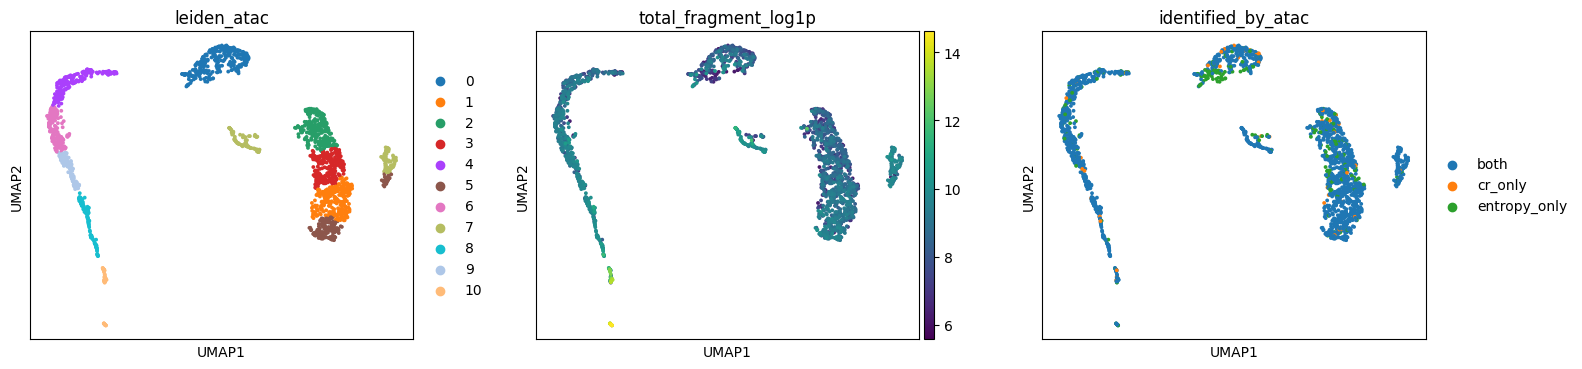

In [82]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_atac_, color=['leiden_atac', 'total_fragment_log1p', 'identified_by_atac'], wspace=0.2, size=30, ncols=3)

<Axes: xlabel='leiden_atac', ylabel='count'>

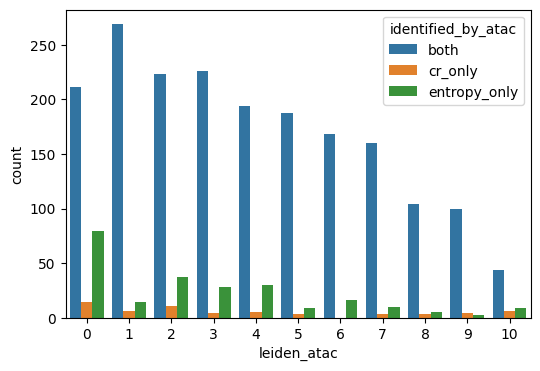

In [83]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=h5_atac_.obs, x='leiden_atac', hue='identified_by_atac', ax=ax)

# Compare Cell-calling approaches

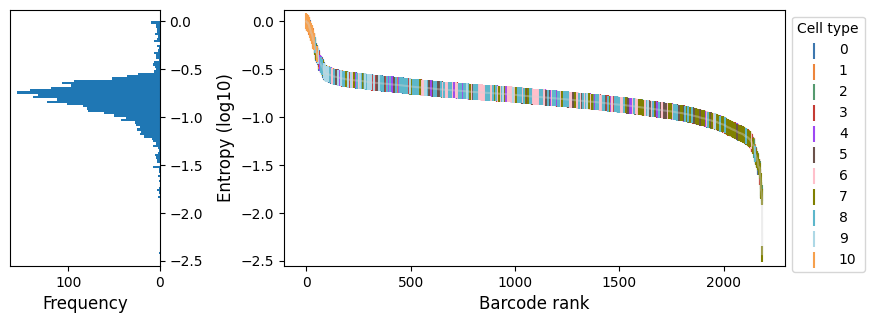

In [53]:
color_order = {'0': '#3d77af', '1': '#ed853b', '2': '#559a6f', '3': '#c53b34', '4': '#9d48f3',
             '5': '#6b524b', '6': 'pink', '7': 'olive', '8': '#5db7cb', '9': 'lightblue', 
                '10': '#f6a04d', '11': '#8fd18b', '12': 'lightcoral'}


fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(30, 20)

ax0 = fig.add_subplot(gs[0:20,0:4])
_ = ax0.hist(np.log10(h5_rna.obs['Entropy']), orientation='horizontal', bins=100)
# move y-tick ro the right side 
ax0.yaxis.tick_right()
ax0.yaxis.set_label_position('right')
ax0.invert_xaxis()
# ax0.set_ylabel('Entropy (log10)', fontsize=12)
ax0.set_xlabel('Frequency', fontsize=12)


ax1 = fig.add_subplot(gs[0:20,7:])


sorted_log10entropy_series = np.log10(h5_rna.obs['Entropy'].sort_values(ascending=False)).to_frame()  # with barcodes as index 
rank_list = np.arange( sorted_log10entropy_series.shape[0] )
sorted_log10entropy_series['rank_list'] = rank_list



ax1.plot( sorted_log10entropy_series['rank_list'], sorted_log10entropy_series['Entropy'], '-', markersize=1, color='lightgray', alpha=0.4)
ax1.set_xlabel('Barcode rank', fontsize=12)
ax1.set_ylabel('Entropy (log10)', fontsize=12)

for ct in [str(i) for i in np.arange(11)]:
    barcodes = h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == ct].index
    ax1.scatter(sorted_log10entropy_series.loc[barcodes, 'rank_list'], 
             sorted_log10entropy_series.loc[barcodes, 'Entropy'], color=color_order[ct], label = ct, s=130, alpha=1, marker="|")
    
    ax1.legend(title='Cell type', bbox_to_anchor=(1, 1), loc='upper left')


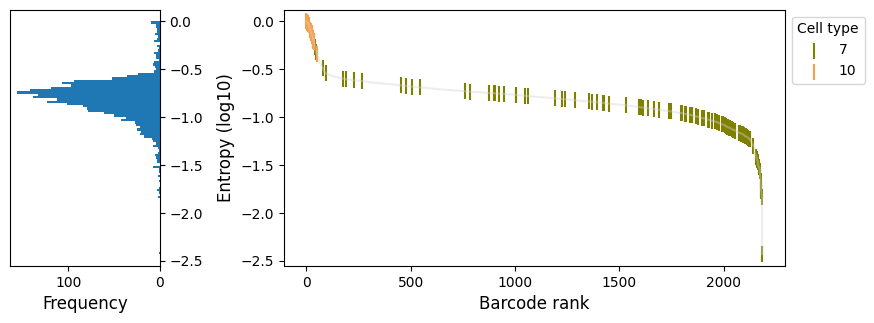

In [54]:
color_order = {'0': '#3d77af', '1': '#ed853b', '2': '#559a6f', '3': '#c53b34', '4': '#9d48f3',
             '5': '#6b524b', '6': 'pink', '7': 'olive', '8': '#5db7cb', '9': 'lightblue', 
                '10': '#f6a04d', '11': '#8fd18b', '12': 'lightcoral'}


fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(30, 20)

ax0 = fig.add_subplot(gs[0:20,0:4])
_ = ax0.hist(np.log10(h5_rna.obs['Entropy']), orientation='horizontal', bins=100)
# move y-tick ro the right side 
ax0.yaxis.tick_right()
ax0.yaxis.set_label_position('right')
ax0.invert_xaxis()
# ax0.set_ylabel('Entropy (log10)', fontsize=12)
ax0.set_xlabel('Frequency', fontsize=12)


ax1 = fig.add_subplot(gs[0:20,7:])


sorted_log10entropy_series = np.log10(h5_rna.obs['Entropy'].sort_values(ascending=False)).to_frame()  # with barcodes as index 
rank_list = np.arange( sorted_log10entropy_series.shape[0] )
sorted_log10entropy_series['rank_list'] = rank_list



ax1.plot( sorted_log10entropy_series['rank_list'], sorted_log10entropy_series['Entropy'], '-', markersize=1, color='lightgray', alpha=0.4)
ax1.set_xlabel('Barcode rank', fontsize=12)
ax1.set_ylabel('Entropy (log10)', fontsize=12)

for ct in [str(i) for i in [7, 10]]:
    barcodes = h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == ct].index
    ax1.scatter(sorted_log10entropy_series.loc[barcodes, 'rank_list'], 
             sorted_log10entropy_series.loc[barcodes, 'Entropy'], color=color_order[ct], label=ct, s=130, alpha=1, marker="|")
    
    ax1.legend(title='Cell type', bbox_to_anchor=(1, 1), loc='upper left')
